<a href="https://colab.research.google.com/github/kledihaxhimali/Data-Science-Projects/blob/Airline-Tickets-Prediction/AirlineTicketsPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Reading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

In [4]:
train_data = pd.read_excel("Data_Train.xlsx")


In [5]:
train_data.head(4)  #print only 4 rows

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218


In [6]:
train_data.tail(4)#print last 4 rows

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


# **DATA CLEANING:** Perform Pre-process & extract derived attributes

In [8]:
train_data.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [9]:
train_data["Total_Stops"].isnull()

,Total_Stops
0,False
1,False
2,False
3,False
4,False
...,...
10678,False
10679,False
10680,False
10681,False


In [10]:
train_data[train_data["Total_Stops"].isnull()]


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [11]:
train_data.dropna(inplace=True) #removes the rows with missing values
train_data.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


In [12]:
train_data.dtypes

,0
Airline,object
Date_of_Journey,object
Source,object
Destination,object
Route,object
Dep_Time,object
Arrival_Time,object
Duration,object
Total_Stops,object
Additional_Info,object


In [13]:
train_data.info(memory_usage= 'deep') #for more detailed information

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Date_of_Journey  10682 non-null  object
 2   Source           10682 non-null  object
 3   Destination      10682 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10682 non-null  object
 6   Arrival_Time     10682 non-null  object
 7   Duration         10682 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10682 non-null  object
 10  Price            10682 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 6.5 MB


In [14]:
data= train_data.copy()
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


In [15]:
def change_into_Datatime(col):
      data[col]=pd.to_datetime(data[col])

In [16]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [17]:
for feature in['Dep_Time', 'Arrival_Time', 'Date_of_Journey']:
  change_into_Datatime(feature)

In [18]:
data.dtypes

,0
Airline,object
Date_of_Journey,datetime64[ns]
Source,object
Destination,object
Route,object
Dep_Time,datetime64[ns]
Arrival_Time,datetime64[ns]
Duration,object
Total_Stops,object
Additional_Info,object


In [19]:
data["Journey_day"]=data['Date_of_Journey'].dt.day
data["Journey_month"]=data['Date_of_Journey'].dt.month
data["Journey_year"]=data['Date_of_Journey'].dt.year

In [20]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2025-09-17 22:20:00,2025-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2025-09-17 05:50:00,2025-09-17 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2025-09-17 09:25:00,2025-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019


In [21]:
def extract_hour_min(df,col):
  df[col+"_hour"]= df[col].dt.hour
  df[col+"_minute"]=df[col].dt.minute
  return df.head(3)

In [22]:
extract_hour_min(data, "Dep_Time")
extract_hour_min(data, "Arrival_Time")

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2025-09-17 22:20:00,2025-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2025-09-17 05:50:00,2025-09-17 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2025-09-17 09:25:00,2025-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019,9,25,4,25


In [23]:
cols_to_drop= ["Arrival_Time", "Dep_Time"]
data.drop(cols_to_drop, axis=1, inplace=True)
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,9,25,4,25


# **Data Analysis**

In [24]:
def flight_departure_time(x):
  if(x  > 4) and (x<=8):
      return "Early Morning"
  elif(x  > 8) and (x<=12):
      return "Morning"
  elif(x  > 12) and (x<=16):
      return "Afternoon"
  elif(x  > 16) and (x<=20):
      return "Evning"
  elif(x  > 20) and (x<=24):
      return "Night"
  else:
      return "Late night"

<Axes: xlabel='Dep_Time_hour'>

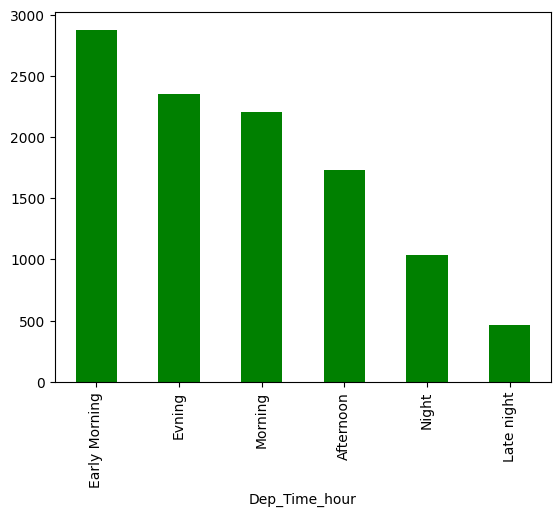

In [25]:
data['Dep_Time_hour'].apply(flight_departure_time).value_counts().plot(kind = "bar", color= "green")

In [26]:
!pip install plotly
!pip install chart_studio
!pip install cufflinks



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.9 MB/s eta 0:00:00


In [27]:
import plotly
import cufflinks as cf
from cufflinks.offline import go_offline
from plotly.offline import plot, iplot, init_notebook_mode, download_plotlyjs
init_notebook_mode(connected= True)
cf.go_offline()

In [28]:
def preprocess_duration(x):
  if 'h' not in x:
    x = '0h' + ' ' + x
  elif 'm' not in x:
    x = x+ ' ' + '0m'
  return x

In [29]:
data['Duration']= data['Duration'].apply(preprocess_duration)
data['Duration']

,Duration
0,2h 50m
1,7h 25m
2,19h 0m
3,5h 25m
4,4h 45m
...,...
10678,2h 30m
10679,2h 35m
10680,3h 0m
10681,2h 40m


In [30]:
int('2h 50m'.split(' ')[1][0:-1])

50

In [31]:
data['Duration_hours'] = data['Duration'].apply(lambda x : int(x.split(' ')[0][0:-1]))
data['Duration_min'] = data['Duration'].apply(lambda x : int(x.split(' ')[1][0:-1]))

In [32]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,6,2019,9,25,4,25,19,0


In [33]:
data['Duration_Total_min']=data['Duration'].str.replace('h', "*60").str.replace(' ', '+').str.replace('m', '*1').apply(eval)
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_min,Duration_Total_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10,2,50,170
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25,445
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,6,2019,9,25,4,25,19,0,1140


<Axes: xlabel='Duration_Total_min', ylabel='Price'>

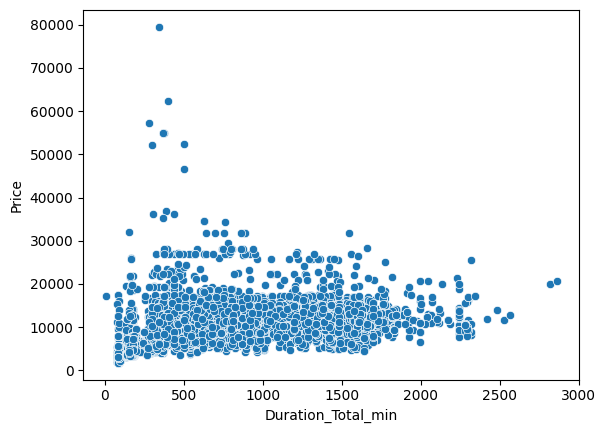

In [34]:
sns.scatterplot(x= "Duration_Total_min", y="Price", data=data)

<Axes: xlabel='Duration_Total_min', ylabel='Price'>

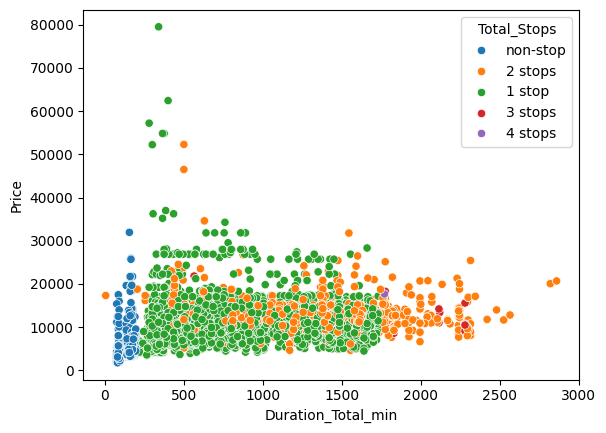

In [35]:
sns.scatterplot(x= "Duration_Total_min", y="Price", hue="Total_Stops",data=data)

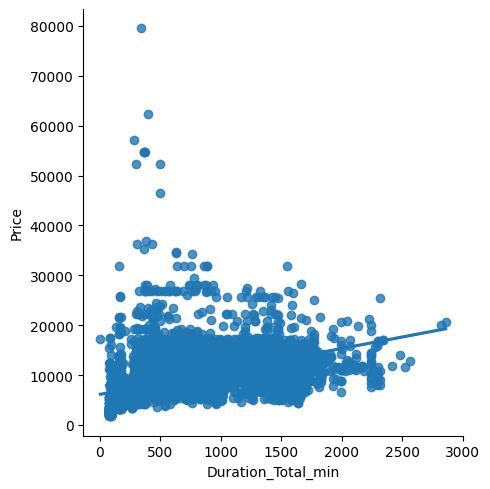

In [36]:
sns.lmplot(x= "Duration_Total_min", y="Price", data=data) #regression plot duration increase price increase

In [37]:
#Check where Jet Airways is mostly used
data['Airline']== 'Jet Airways'
data[data['Airline']== 'Jet Airways'].groupby('Route').size().sort_values(ascending=False)



,0
Route,
CCU → BOM → BLR,930
DEL → BOM → COK,875
BLR → BOM → DEL,385
BLR → DEL,382
CCU → DEL → BLR,300
DEL → JAI → BOM → COK,207
BOM → HYD,207
DEL → AMD → BOM → COK,141
DEL → IDR → BOM → COK,86


In [38]:
#Airline vs Price analysis

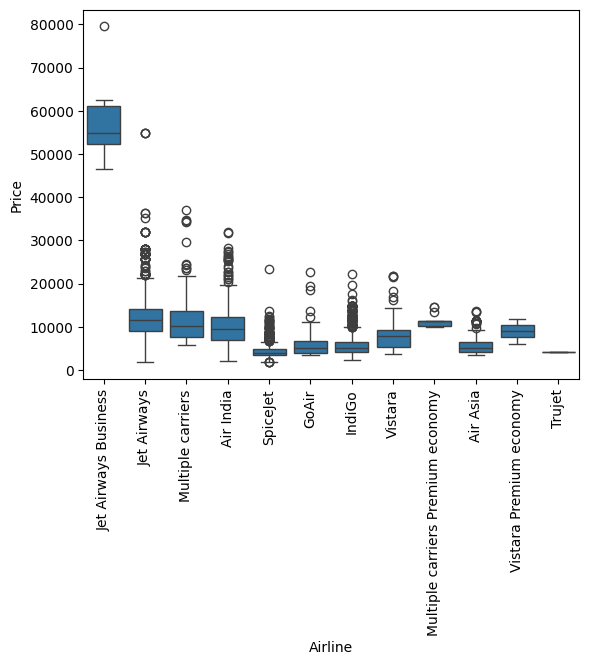

In [39]:
sns.boxplot(x= "Airline", y="Price", data=data.sort_values("Price", ascending=False))
plt.xticks(rotation="vertical")
plt.show()

# **Feature Engineering** ---> One Hot Encoding

In [40]:
#Feature engoding ----> Convert categorical data to numerical data in order to be used in ML model
#Nominal data , use one hot encoding
#Ordinal data, use label encoding

In [41]:
cat_col =[col for col in data.columns if data[col].dtype == "object"]
num_col =[col for col in data.columns if data[col].dtype != "object"]

cat_col

['Airline',
 'Source',
 'Destination',
 'Route',
 'Duration',
 'Total_Stops',
 'Additional_Info']

In [42]:
data["Source"].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [43]:
data['Source'].apply(lambda x: 1 if x== "Banglore" else 0)

,Source
0,1
1,0
2,0
3,0
4,1
...,...
10678,0
10679,0
10680,1
10681,1


In [44]:
for sub_category in data ["Source"].unique():
  data['Source_'+ sub_category]= data["Source"].apply(lambda x:1 if x==sub_category else 0)

In [45]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_min,Duration_Total_min,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,...,4,25,19,0,1140,0,0,1,0,0


In [46]:
data['Airline'].unique()
#because of high dimensionality we use optimized feature encoding

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [47]:
airlines=  data.groupby(["Airline"])['Price'].mean().sort_values().index

In [48]:
airlines

Index(['Trujet', 'SpiceJet', 'Air Asia', 'IndiGo', 'GoAir', 'Vistara',
       'Vistara Premium economy', 'Air India', 'Multiple carriers',
       'Multiple carriers Premium economy', 'Jet Airways',
       'Jet Airways Business'],
      dtype='object', name='Airline')

In [49]:
dict_airlines = {key: index for index, key in enumerate(airlines, 0)}
dict_airlines

{'Trujet': 0,
 'SpiceJet': 1,
 'Air Asia': 2,
 'IndiGo': 3,
 'GoAir': 4,
 'Vistara': 5,
 'Vistara Premium economy': 6,
 'Air India': 7,
 'Multiple carriers': 8,
 'Multiple carriers Premium economy': 9,
 'Jet Airways': 10,
 'Jet Airways Business': 11}

In [50]:
data['Airline'] = data['Airline'].map(dict_airlines)
data['Airline']

,Airline
0,3
1,7
2,10
3,3
4,3
...,...
10678,2
10679,7
10680,10
10681,5


In [51]:
data['Destination'].unique()

array(['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad'],
      dtype=object)

In [52]:
data['Destination'].replace("New Delhi", "Delhi", inplace=True) #Same data with different names
data['Destination'].unique()

array(['Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Hyderabad'],
      dtype=object)

In [53]:
dest= data.groupby(['Destination'])['Price'].mean().sort_values().index
dict_dest={key:index for index, key in enumerate(dest,0)}
dict_dest

{'Kolkata': 0, 'Hyderabad': 1, 'Delhi': 2, 'Banglore': 3, 'Cochin': 4}

In [54]:
data["Destination"]=data["Destination"].map(dict_dest)
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_min,Duration_Total_min,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,2,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,...,4,25,19,0,1140,0,0,1,0,0


Preform Manual Encodin on Data/
    Remove unnecessary features

In [55]:
data["Total_Stops"]

,Total_Stops
0,non-stop
1,2 stops
2,2 stops
3,1 stop
4,1 stop
...,...
10678,non-stop
10679,non-stop
10680,non-stop
10681,non-stop


In [56]:
data["Total_Stops"].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [57]:
stop = {'non-stop':0, '2 stops':2, '1 stop':1, '3 stops':3, '4 stops':4}

In [58]:
data["Total_Stops"]=data["Total_Stops"].map(stop)
data["Total_Stops"]

,Total_Stops
0,0
1,2
2,2
3,1
4,1
...,...
10678,0
10679,0
10680,0
10681,0


In [59]:
data.head(1)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_min,Duration_Total_min,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,2,BLR → DEL,2h 50m,0,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0


In [60]:
data["Additional_Info"].value_counts()/len(data)*100 #To check the amount of empty info

,count
Additional_Info,
No info,78.112713
In-flight meal not included,18.554578
No check-in baggage included,2.995694
1 Long layover,0.177869
Change airports,0.065531
Business class,0.037446
No Info,0.028085
1 Short layover,0.009362
Red-eye flight,0.009362


In [61]:
data.head(4)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_min,Duration_Total_min,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,2,BLR → DEL,2h 50m,0,No info,3897,24,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662,1,...,13,15,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,19h 0m,2,No info,13882,9,...,4,25,19,0,1140,0,0,1,0,0
3,3,2019-05-12,Kolkata,3,CCU → NAG → BLR,5h 25m,1,No info,6218,12,...,23,30,5,25,325,0,1,0,0,0


In [62]:
data.drop(columns= ['Date_of_Journey', 'Route', 'Additional_Info', 'Duration_Total_min', 'Source', 'Journey_year', 'Duration'], axis=1, inplace=True)

In [63]:
data.columns

Index(['Airline', 'Destination', 'Total_Stops', 'Price', 'Journey_day',
       'Journey_month', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hours',
       'Duration_min', 'Source_Banglore', 'Source_Kolkata', 'Source_Delhi',
       'Source_Chennai', 'Source_Mumbai'],
      dtype='object')

In [64]:
data.head(3)

,Airline,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_min,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2,0,3897,24,3,22,20,1,10,2,50,1,0,0,0,0
1,7,3,2,7662,1,5,5,50,13,15,7,25,0,1,0,0,0
2,10,4,2,13882,9,6,9,25,4,25,19,0,0,0,1,0,0


**`Perform outlier detection / how to deal with it`**

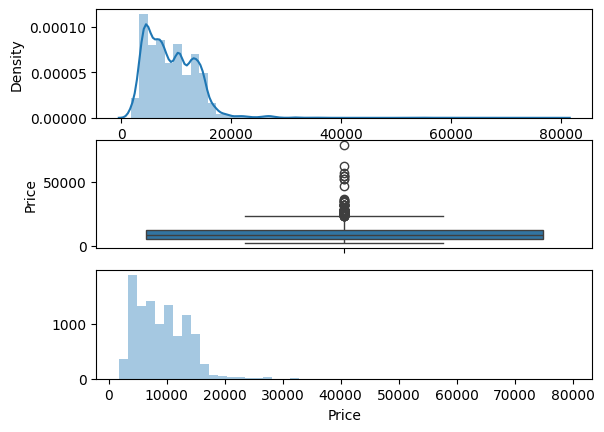

In [65]:
def plot(df, col):
  fig, (ax1, ax2, ax3) = plt.subplots(3,1)
  sns.distplot(df[col], ax=ax1)
  sns.boxplot(df[col], ax=ax2)
  sns.distplot(df[col], ax=ax3, kde=False)

plot(data, 'Price')

In [66]:
q1= data['Price']. quantile(0.25)
q3= data['Price'].quantile (0.75)
iqr= q3- q1
maximum = q3+ 1.5*iqr
minimum = q1 - 1.5*iqr



In [67]:
print(maximum)

23017.0


In [68]:
print(minimum)

-5367.0


In [69]:
print([price for price in data['Price'] if price> maximum or price< minimum])#outliers

[27430, 36983, 26890, 26890, 25139, 27210, 52229, 26743, 26890, 25735, 27992, 26890, 26890, 23583, 26890, 23533, 24115, 25735, 54826, 31783, 27992, 26890, 26890, 25430, 36235, 27210, 26890, 25735, 54826, 26890, 35185, 79512, 28097, 27992, 26890, 25735, 26092, 31825, 25913, 25735, 27992, 31825, 23267, 62427, 54826, 31825, 25430, 26890, 36235, 23843, 26890, 25735, 28322, 25735, 25735, 31825, 26890, 27992, 34273, 46490, 29528, 26890, 26890, 26890, 34503, 26890, 27992, 26890, 26890, 23170, 24528, 26890, 27992, 25735, 34608, 25703, 26890, 23528, 31825, 27282, 25735, 27992, 52285, 24017, 31945, 26890, 24318, 23677, 27992, 24210, 57209, 26890, 31825, 26480]


In [70]:
len([price for price in data['Price'] if price> maximum or price< minimum]) #Number of outliers

94

In [71]:
np.where(data['Price']>=35000, data["Price"].median(), data['Price'])

array([ 3897.,  7662., 13882., ...,  7229., 12648., 11753.])

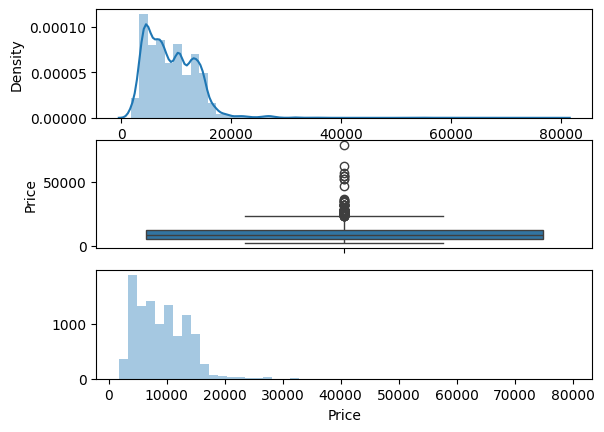

In [72]:
plot(data, 'Price')

**Feature Selection** --> Independent and dependent feature

In [73]:
#Mutual information approach / return nonnegative values
X =data.drop(['Price'], axis=1)
y= data["Price"]
from sklearn.feature_selection import mutual_info_regression
imp =mutual_info_regression(X,y)
imp_df = pd.DataFrame(imp, index= X.columns)
imp_df.columns= ['Importance'] #to add a head on the column
imp_df


,Importance
Airline,1.328098
Destination,1.076502
Total_Stops,0.786982
Journey_day,0.374139
Journey_month,0.616101
Dep_Time_hour,0.927321
Dep_Time_minute,0.758136
Arrival_Time_hour,1.142825
Arrival_Time_minute,0.899874
Duration_hours,1.120870


In [74]:
imp_df.sort_values(by='Importance', ascending=False) # we dont remove anyt outlier when we have a small dataset

,Importance
Airline,1.328098
Arrival_Time_hour,1.142825
Duration_hours,1.120870
Destination,1.076502
Dep_Time_hour,0.927321
Arrival_Time_minute,0.899874
Total_Stops,0.786982
Dep_Time_minute,0.758136
Duration_min,0.676327
Journey_month,0.616101


# **Build ML model**

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

from sklearn.ensemble import RandomForestRegressor
ml_model= RandomForestRegressor()
ml_model.fit(X_train, y_train)

y_pred= ml_model.predict(X_test)
y_pred

array([16810.95,  5412.55,  8762.85, ...,  3541.78,  6274.42,  6854.21])

In [76]:
from sklearn import metrics
metrics.r2_score(y_test, y_pred)

0.8030148903226992

In [77]:
!pip install pickle

ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


In [78]:
import pickle
file= open("rf_random.pkl", 'wb')
pickle.dump(ml_model, file)
model= open(r"rf_random.pkl", 'rb')
forest = pickle.load(model)
y_pred=forest.predict(X_test)
metrics.r2_score(y_test, y_pred)

0.8030148903226992

# **Evaluation Metrix (How to automate ML pipeline)**

In [79]:
def mape(y_true, y_pred): #mean absolute percentage error
  y_true, y_pred= np.array(y_true), np.array(y_pred)
  return np.mean(np.abs(y_true-y_pred)/y_true)*100
mape(y_test, y_pred)

np.float64(13.055748172502406)

Training Score: 0.9544982429193655
Predictions are :[16851.06  5434.01  8653.71 ...  3565.04  6232.04  6897.69]


r2_score : 0.8030148903226992
MAE : 1177.7384460547983
MSE : 4140868.7301930594
RMSE : 4140868.7301930594
MAPE : 13.157918283636302


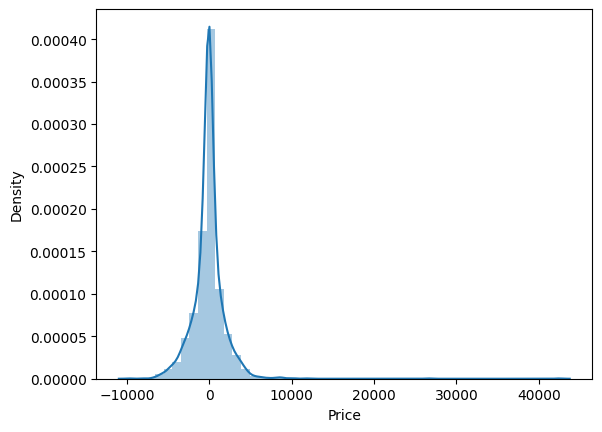

In [80]:
def predict(ml_model):
  model= ml_model.fit(X_train, y_train)
  print('Training Score: {}'.format(model.score(X_train, y_train)))
  y_prediction= model.predict(X_test)
  print('Predictions are :{}'.format(y_prediction))
  print('\n')
  r2_score= metrics.r2_score(y_test, y_pred)
  print('r2_score : {}'.format(r2_score))
  print('MAE : {}'.format(metrics.mean_absolute_error(y_test, y_prediction)))
  print('MSE : {}'.format(metrics.mean_squared_error(y_test, y_prediction)))
  print('RMSE : {}'.format(metrics.mean_squared_error(y_test,y_prediction)))
  print('MAPE : {}'.format(mape(y_test, y_prediction)))
  sns.distplot(y_test - y_prediction)
predict(RandomForestRegressor())

Training Score: 0.9707490055980877
Predictions are :[16840.  4959.  8085. ...  3419.  5797.  6442.]


r2_score : 0.8030148903226992
MAE : 1389.7675402470984
MSE : 6235190.989114564
RMSE : 6235190.989114564
MAPE : 15.382461389337667


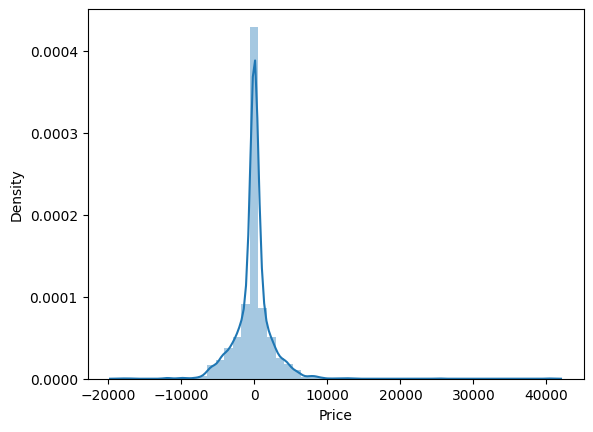

In [81]:
from  sklearn.tree import DecisionTreeRegressor
predict(DecisionTreeRegressor())

**How to hypertune a ML model**

In [82]:
#optimize hyper parameters
from sklearn.model_selection import RandomizedSearchCV
reg_rf= RandomForestRegressor()
np.linspace(start= 100, stop= 1200, num=6)
n_estimators= [int(x) for x in np.linspace(start= 100, stop= 1200, num=6)]

max_features = ["auto", 'sqrt']
max_depth = [int(x) for x in np.linspace(start= 100, stop= 1200, num=6)]
min_spamples_split = [5,10,15,100]
random_grid = {
    'n_estimators' : n_estimators,
    'max_features' : max_features,
    'max_depth' : max_depth,
    'min_samples_split' : min_spamples_split
}
random_grid

{'n_estimators': [100, 320, 540, 760, 980, 1200],
 'max_features': ['auto', 'sqrt'],
 'max_depth': [100, 320, 540, 760, 980, 1200],
 'min_samples_split': [5, 10, 15, 100]}

In [83]:
rf_random = RandomizedSearchCV(estimator=reg_rf, param_distributions=random_grid, cv=3, n_jobs= -1, verbose=2)
rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
                   param_distributions={'max_depth': [100, 320, 540, 760, 980,
                                                      1200],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_split': [5, 10, 15, 100],
                                        'n_estimators': [100, 320, 540, 760,
                                                         980, 1200]},
                   verbose=2)

In [84]:
rf_random.best_params_

{'n_estimators': 980,
 'min_samples_split': 5,
 'max_features': 'sqrt',
 'max_depth': 320}

In [85]:
rf_random.best_estimator_

RandomForestRegressor(max_depth=320, max_features='sqrt', min_samples_split=5,
                      n_estimators=980)